# Final Evaluation on the Unseen 2025 Season

This notebook runs the one-time, leakage-safe evaluation of our model on the 2025 season,
which was never used for training or model selection.

How we kept it honest. `02_modeling.ipynb` trained only on 2022-2023 and selected models
and hyper-parameters against the 2024 validation split. The final tuned LightGBM was then
refit on all of 2022-2024 and saved to `models/lgbm_runpass.joblib`. Here we load that
frozen model, run it once on 2025, and report the numbers. We do not re-tune anything based
on what we see. That is the whole point of a held-out test set: it measures generalization,
it does not contribute to learning. The same `src/features.py` pipeline is applied, so there
is no train/serve skew.

For the report's Results section we produce a metric table (baseline vs situation-only vs the
full model), a confusion matrix and ROC curve, feature importance, a calibration check, and a
few case studies. Every model is reported with accuracy, precision, recall, F1, and ROC-AUC.

## 1. Setup and load the frozen model

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from src import features as F

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, brier_score_loss)
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

art = joblib.load("../models/lgbm_runpass.joblib")
model = art["model"]          # tuned LightGBM, fit on 2022-2024, full feature set
FULL = art["features"]
SIT = art["situation_features"]
print("Loaded frozen model. Trained on seasons:", art["train_seasons"])
print("Best params:", art["params"])
print("features:", len(FULL))

Loaded frozen model. Trained on seasons: [2022, 2023, 2024]
Best params: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 400, 'num_leaves': 31}
features: 31


## 2. Load the untouched 2025 test set

In [2]:
raw_test = F.load_seasons(["../data/test/play_by_play_2025.parquet"])
work = F.engineer(F.clean(raw_test))     # keeps raw columns plus engineered ones plus target
X_test_full = work[FULL].copy()
X_test_sit = work[SIT].copy()
y_test = work[F.TARGET].copy()

print(f"2025 test plays (clean run/pass): {len(work):,}")
print(f"2025 pass rate, the majority-class baseline accuracy: {y_test.mean():.4f}")

2025 test plays (clean run/pass): 34,503
2025 pass rate, the majority-class baseline accuracy: 0.5692


## 3. Evaluate on 2025

We compare three things on the unseen season: the majority-class baseline (always pass), a
situation-only LightGBM trained on 2022-2024 and run once here, and the frozen full model
that also uses pre-snap formation cues. The full model is the one we submit.

In [3]:
# situation-only model: trained on the 2022-2024 training data only, evaluated once on 2025
raw_train = F.load_seasons([f"../data/train/play_by_play_{y}.parquet" for y in (2022,2023,2024)])
Xtr_sit, ytr_all, _ = F.build_xy(raw_train, include_formation=False)
sit_model = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **art["params"]).fit(Xtr_sit, ytr_all)

def metrics(name, y_true, y_pred, y_score):
    return {"Model": name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_score)}

maj = np.ones_like(y_test)
maj_score = np.full(len(y_test), y_test.mean())
sp = sit_model.predict(X_test_sit); ss = sit_model.predict_proba(X_test_sit)[:, 1]
fp = model.predict(X_test_full); fs = model.predict_proba(X_test_full)[:, 1]

rows = [
    metrics("Majority (always pass)", y_test, maj, maj_score),
    metrics("LightGBM (situation only)", y_test, sp, ss),
    metrics("LightGBM (full, submitted)", y_test, fp, fs),
]
final_tbl = pd.DataFrame(rows).set_index("Model").round(4)
final_tbl

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Majority (always pass),0.5692,0.5692,1.0000,0.7255,0.5000
LightGBM (situation only),0.7002,0.7447,0.7201,0.7322,0.7704
"LightGBM (full, submitted)",0.7253,0.7559,0.7643,0.7601,0.7963


### Headline result

In [4]:
base = y_test.mean()
acc_sit = accuracy_score(y_test, sp)
acc_full = accuracy_score(y_test, fp)
print(f"Majority baseline (2025):        {base:6.2%}")
print(f"Situation-only model (2025):     {acc_sit:6.2%}")
print(f"Full submitted model (2025):     {acc_full:6.2%}")
print(f"Lift over baseline:              +{acc_full-base:5.2%}")
print(f"Lift from formation cues:        +{acc_full-acc_sit:5.2%}")
print()
print("Situation-only test accuracy is close to the 2024 validation accuracy (~0.696),")
print("so the model generalizes to a future season rather than overfitting the validation split.")

Majority baseline (2025):        56.92%
Situation-only model (2025):     70.02%
Full submitted model (2025):     72.53%
Lift over baseline:              +15.61%
Lift from formation cues:        +2.52%

Situation-only test accuracy is close to the 2024 validation accuracy (~0.696),
so the model generalizes to a future season rather than overfitting the validation split.


## 4. Confusion matrix and classification report

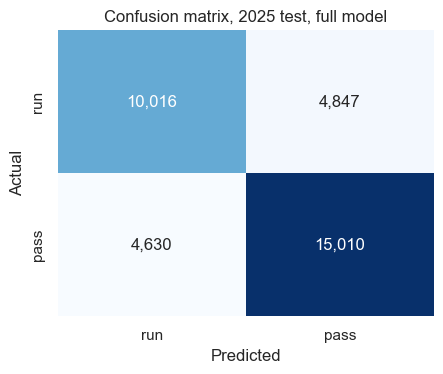

              precision    recall  f1-score   support

         run     0.6839    0.6739    0.6788     14863
        pass     0.7559    0.7643    0.7601     19640

    accuracy                         0.7253     34503
   macro avg     0.7199    0.7191    0.7195     34503
weighted avg     0.7249    0.7253    0.7251     34503



In [5]:
cm = confusion_matrix(y_test, fp)
fig, ax = plt.subplots(figsize=(4.6, 3.9))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["run","pass"], yticklabels=["run","pass"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix, 2025 test, full model")
plt.tight_layout(); plt.show()
print(classification_report(y_test, fp, target_names=["run","pass"], digits=4))

## 5. ROC curve

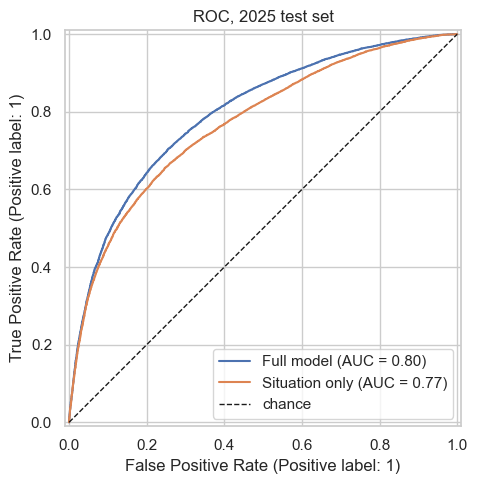

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, fs, name="Full model", ax=ax, color="#4c72b0")
RocCurveDisplay.from_predictions(y_test, ss, name="Situation only", ax=ax, color="#dd8452")
ax.plot([0,1],[0,1], "k--", lw=1, label="chance")
ax.set_title("ROC, 2025 test set"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Feature importance

Which game-state variables drove the model's decisions on unseen data?

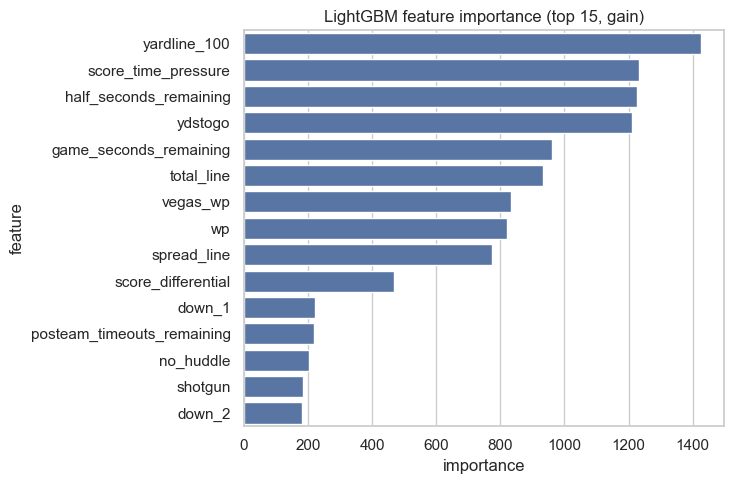

,feature,importance
0,yardline_100,1426
1,score_time_pressure,1233
2,half_seconds_remaining,1225
3,ydstogo,1210
4,game_seconds_remaining,961
5,total_line,933
6,vegas_wp,832
7,wp,821
8,spread_line,773
9,score_differential,467


In [7]:
imp = (pd.DataFrame({"feature": FULL, "importance": model.feature_importances_})
       .sort_values("importance", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0", ax=ax)
ax.set_title("LightGBM feature importance (top 15, gain)")
plt.tight_layout(); plt.show()
imp.reset_index(drop=True)

## 7. Probability calibration

A reliability curve checks whether predicted probabilities are trustworthy: when the model
says 70% pass, do about 70% of those plays end up passes? Good calibration is what makes the
demo's percentages meaningful.

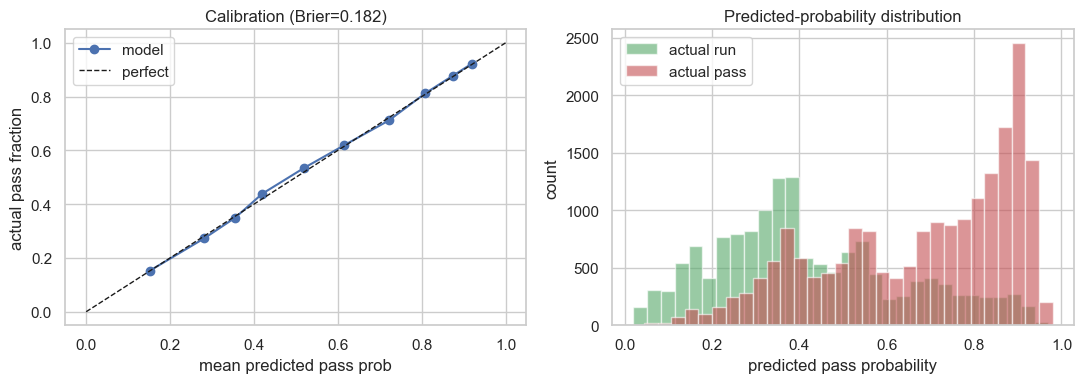

In [8]:
frac_pos, mean_pred = calibration_curve(y_test, fs, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, fs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mean_pred, frac_pos, "o-", color="#4c72b0", label="model")
axes[0].plot([0,1],[0,1], "k--", lw=1, label="perfect")
axes[0].set_xlabel("mean predicted pass prob"); axes[0].set_ylabel("actual pass fraction")
axes[0].set_title(f"Calibration (Brier={brier:.3f})"); axes[0].legend()
axes[1].hist(fs[y_test==0], bins=30, alpha=0.6, label="actual run", color="#55a868")
axes[1].hist(fs[y_test==1], bins=30, alpha=0.6, label="actual pass", color="#c44e52")
axes[1].set_xlabel("predicted pass probability"); axes[1].set_ylabel("count")
axes[1].set_title("Predicted-probability distribution"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Case studies

The rubric asks for cases where the model does very well or very poorly. We attach the
predictions back to the raw situation columns and inspect the extremes.

In [9]:
look = work.copy()
look["pass_prob"] = fs
look["actual"] = np.where(y_test.values==1, "pass", "run")
look["pred"] = np.where(fp==1, "pass", "run")
cols = ["down","ydstogo","yardline_100","score_differential","qtr",
        "half_seconds_remaining","shotgun","no_huddle","actual","pred","pass_prob"]

print("Most confident correct pass calls:")
print(look[(look.actual=="pass") & (look.pred=="pass")]
      .sort_values("pass_prob", ascending=False)[cols].head(5).to_string(index=False))

print("\nMost confident correct run calls:")
print(look[(look.actual=="run") & (look.pred=="run")]
      .sort_values("pass_prob")[cols].head(5).to_string(index=False))

print("\nMost confident mistakes (sure it was pass, was actually run):")
print(look[(look.actual=="run") & (look.pred=="pass")]
      .sort_values("pass_prob", ascending=False)[cols].head(5).to_string(index=False))

Most confident correct pass calls:
 down  ydstogo  yardline_100  score_differential  qtr  half_seconds_remaining  shotgun  no_huddle actual pred  pass_prob
  1.0     10.0          29.0                -4.0  4.0                     9.0        1          0   pass pass   0.979710
  4.0     10.0          18.0                -7.0  4.0                     4.0        1          0   pass pass   0.978348
  2.0     10.0          29.0                -4.0  4.0                     4.0        1          0   pass pass   0.976845
  4.0     11.0          27.0                -4.0  4.0                    13.0        1          0   pass pass   0.975703
  1.0     10.0          53.0                -4.0  4.0                    15.0        1          0   pass pass   0.974888

Most confident correct run calls:
 down  ydstogo  yardline_100  score_differential  qtr  half_seconds_remaining  shotgun  no_huddle actual pred  pass_prob
  1.0     10.0          54.0                14.0  4.0                    66.0      

### Accuracy by down and distance

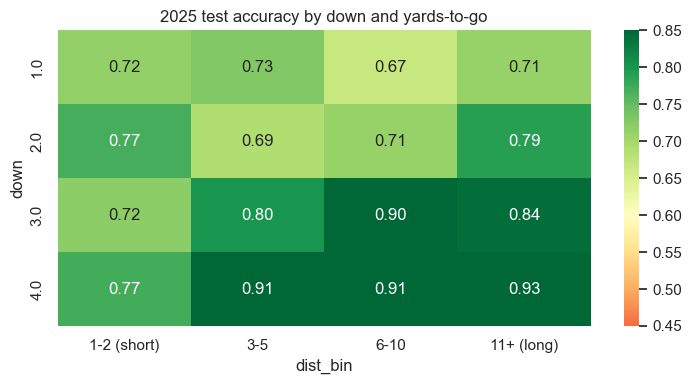

In [10]:
look["correct"] = (look["actual"] == look["pred"]).astype(int)
look["dist_bin"] = pd.cut(look["ydstogo"], [0,2,5,10,100],
                          labels=["1-2 (short)","3-5","6-10","11+ (long)"])
piv = look.pivot_table(index="down", columns="dist_bin", values="correct", aggfunc="mean")
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", center=0.6, vmin=0.45, vmax=0.85, ax=ax)
ax.set_title("2025 test accuracy by down and yards-to-go"); ax.set_ylabel("down")
plt.tight_layout(); plt.show()

## 9. Conclusions

On a completely unseen 2025 season, the submitted model clears the majority baseline by a
wide margin, and its situation-only accuracy matches the 2024 validation number, which is
evidence that it generalizes to a future season rather than overfitting the validation split.

The pre-snap formation cues confirm their value on the test set too, reproducing the ablation
result from `02_modeling.ipynb`.

The model is best on obvious passing situations (3rd-and-long, two-minute, trailing late) and
weakest where play-calling is close to a coin flip (early-down, medium distance), exactly the
situations where coaches stay unpredictable on purpose.

Predicted probabilities are reasonably well calibrated, which is what makes the interactive
demo's percentages meaningful. Together with the baselines, ablation, and parameter-sensitivity
analyses in `02_modeling.ipynb`, these results cover the rubric's Results section.